# Introduction to Quantum Computing with IBM Qiskit

### Srisuphadith Rattanaprasert 66070501052

### Pre-requisites

1. Qiskit: our main module
2. qiskit-aer: used to simulate quantum circuit on local classical computer
3. qiskit[visualization] (optional: for visualize circuit with matplotlib)
4. qiskit-ibm-runtime: used to get backend (or fake beckend) quantum device

For more information on how to install IBM Qiskit, please refer to the [documentation](https://qiskit.org/documentation/getting_started.html).

In [165]:
!pip install -q qiskit
!pip install -q qiskit[visualization]
!pip install -q qiskit-aer
!pip install -q qiskit-ibm-runtime



---



### Hands-on
After this we can begin coding with IBM Qiskit 🙌

#### Hello World with Qiskit (and Qiskit composer)

In [166]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

backend = AerSimulator()

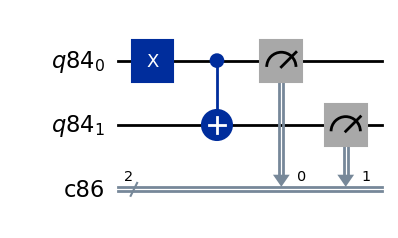

In [167]:
qr = QuantumRegister(2)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)

circuit.x(qr[0])
circuit.cx(qr[0], qr[1])
circuit.measure(qr[0], cr[0])
circuit.measure(qr[1], cr[1])

circuit.draw('mpl')

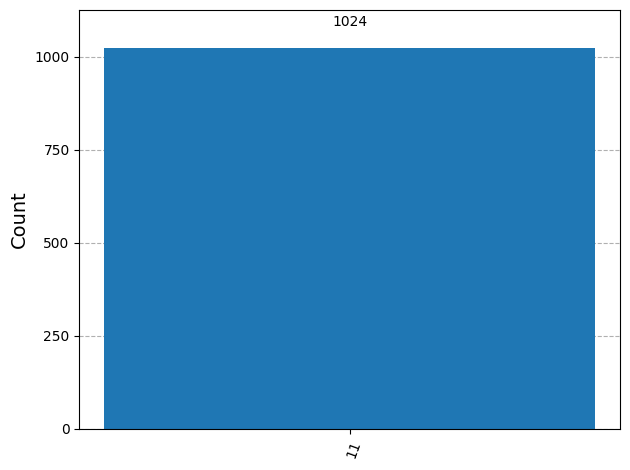

In [168]:
transpiled_circuit = transpile(circuit, backend)

# Run the transpiled circuit using the aer simulator
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

####  create a single-qubit superposition state  |+> with hadamard gate act on |0>

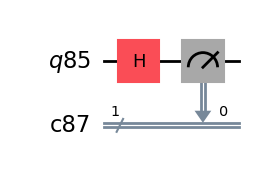

In [169]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)

circuit.h(qr[0])
circuit.measure(qr[0], cr[0])

circuit.draw('mpl')

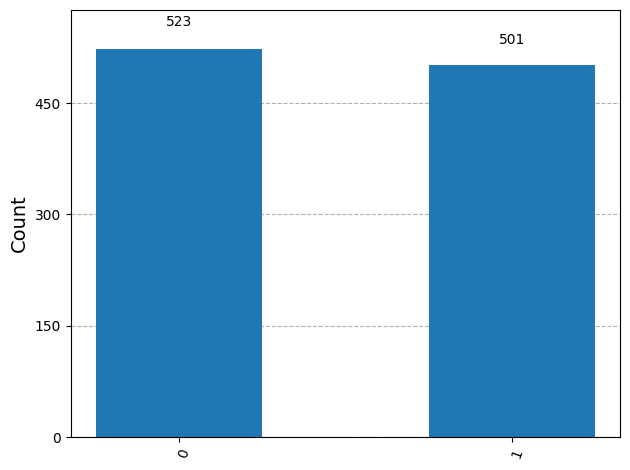

In [170]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

#### create a single-qubit superposition state  |-> with hadamard gate act on |1>

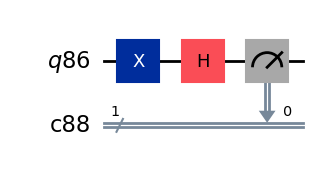

In [171]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)

circuit.x(qr[0])
circuit.h(qr[0])
circuit.measure(qr[0], cr[0])

circuit.draw('mpl')

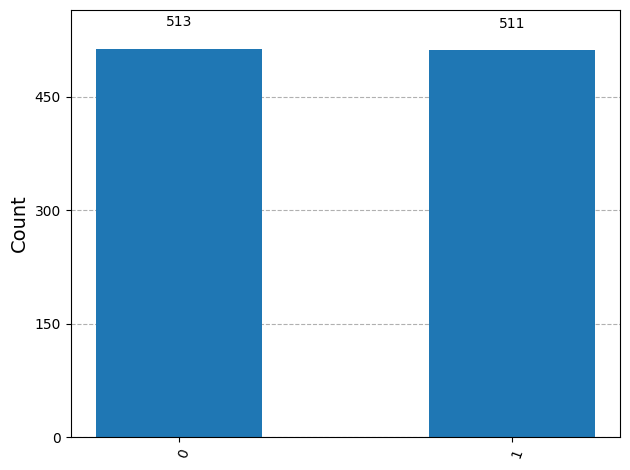

In [172]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

#### Exercise 1: Half-Adder
Create Half-Adder Quantum Circuit with Qiskit Composer

and show the solution when input is 000, 001, 010, 011, 100, 101, 110, and 111

Pseudocode for Half-Adder circuit

#XOR
1. put CNOT gate, control on qubit 1, targer on qubit 2
2. put CNOT gate, control on qubit 0, targer on qubit 2

#AND

3. put toffoli gate (CCNOT), control on qubit 0 and qubit 1, targer on qubit 3

hint: this can be done using ccx(control1,control2,target)

#Sum

4. measure qubit 2 to classical register 0

#Carry out

5. measure qubit 3 to classical register 1

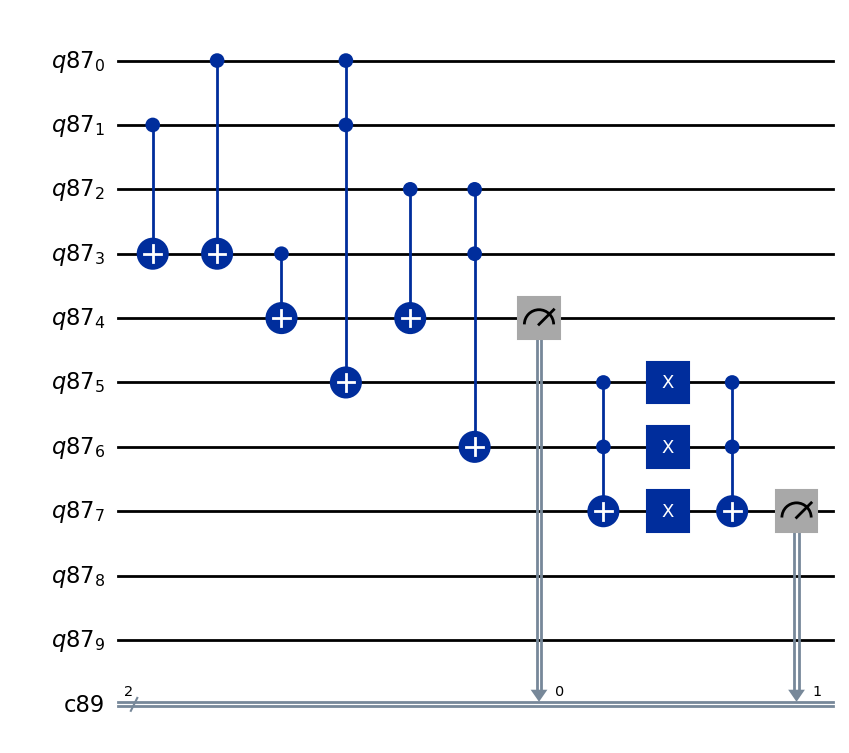

In [173]:
#circuit for 000
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

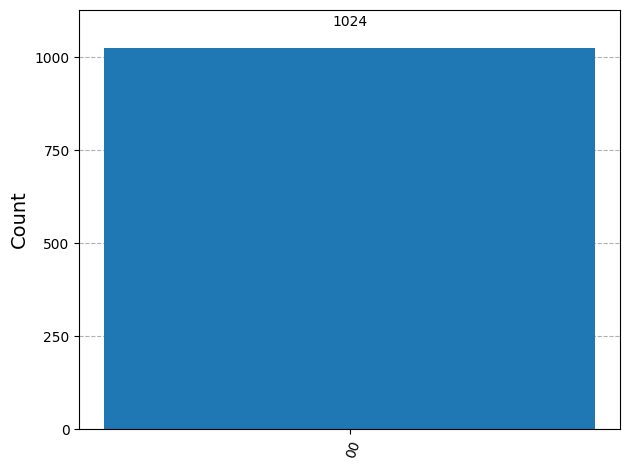

In [174]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

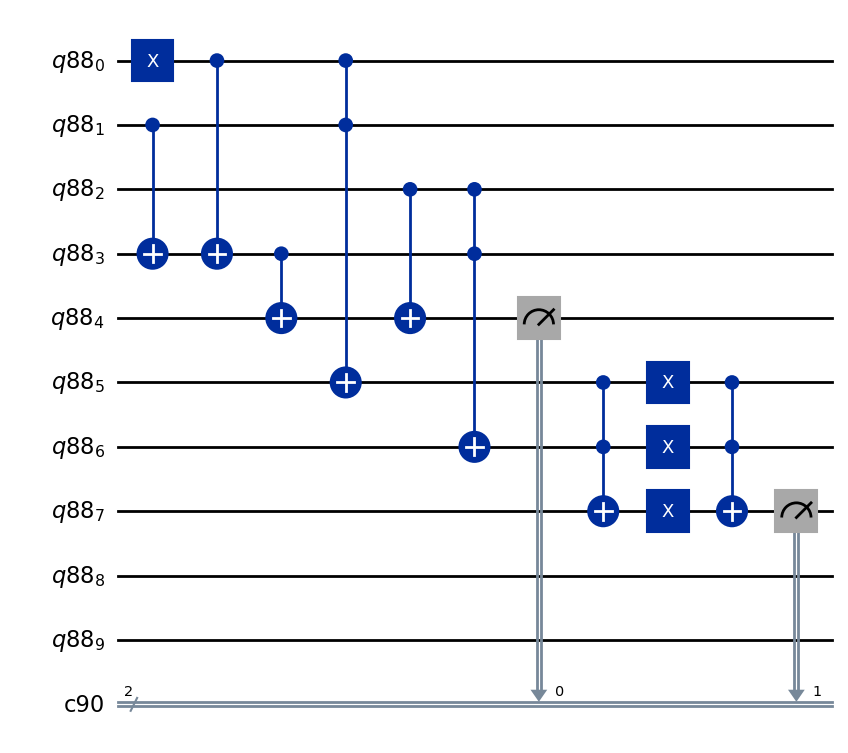

In [175]:
#circuit for 001
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[0])
circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

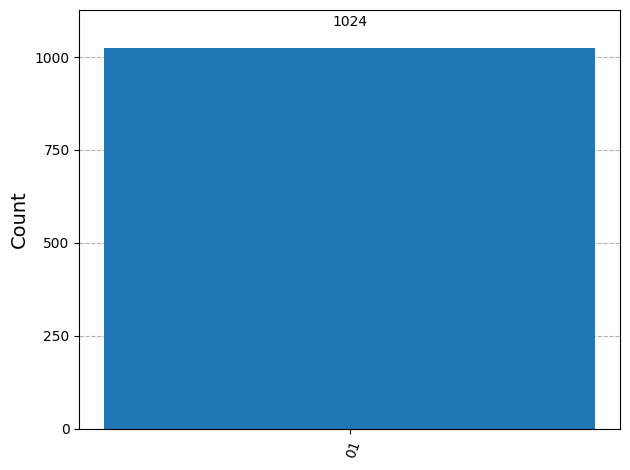

In [176]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

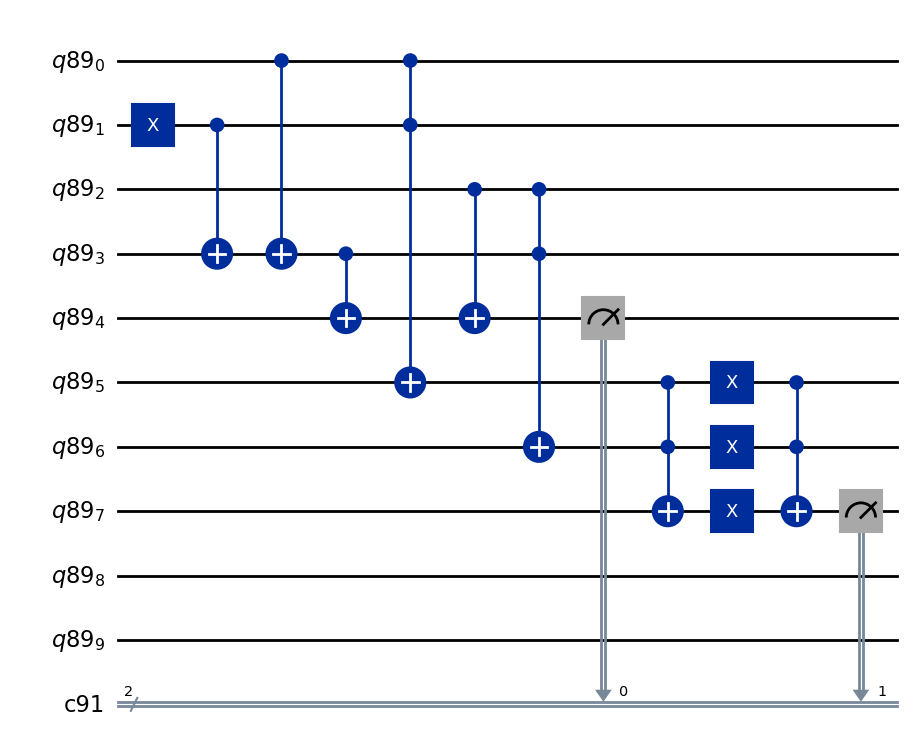

In [177]:
#circuit for 010
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[1])

circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

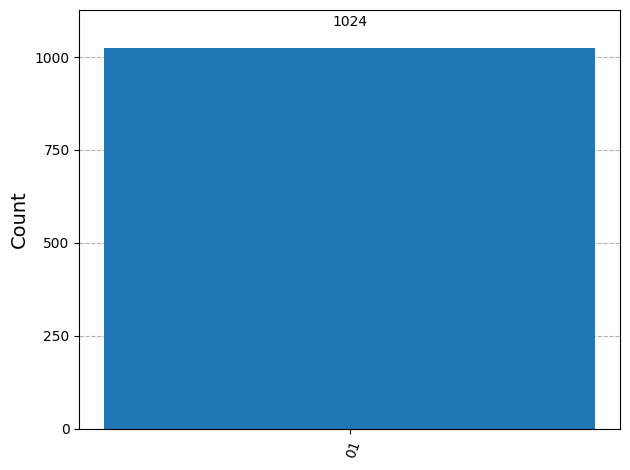

In [178]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

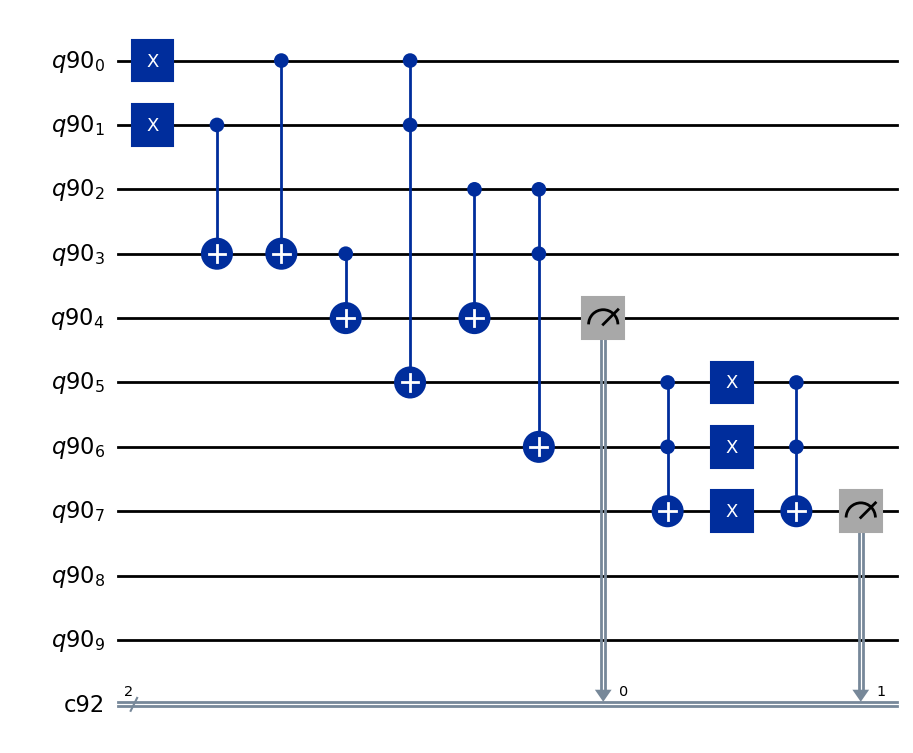

In [179]:
#circuit for 011
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[0])
circuit.x(qr[1])

circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

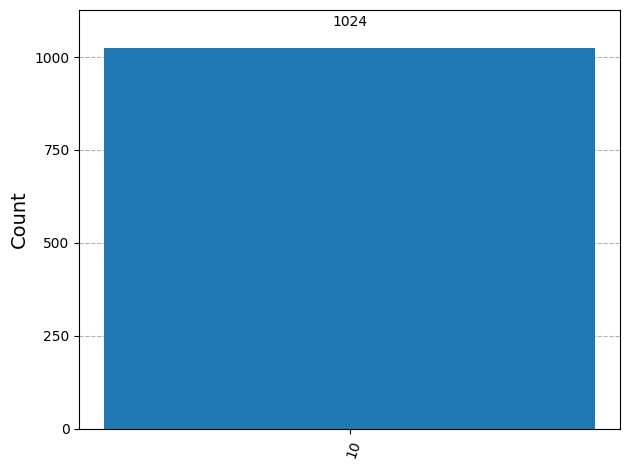

In [180]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

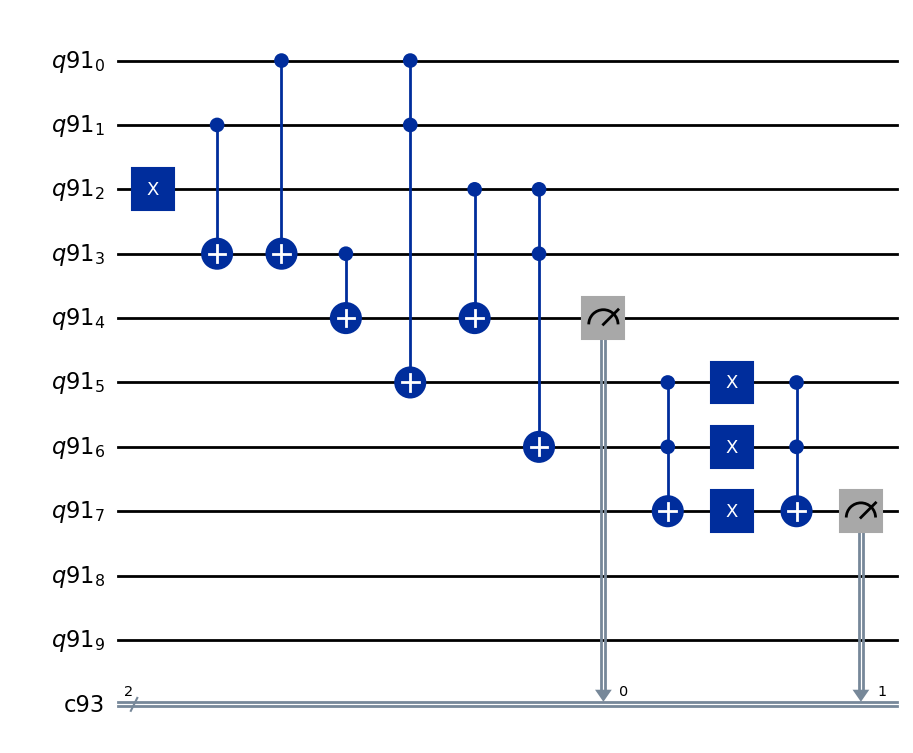

In [ ]:
#circuit for 100
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[2])

circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

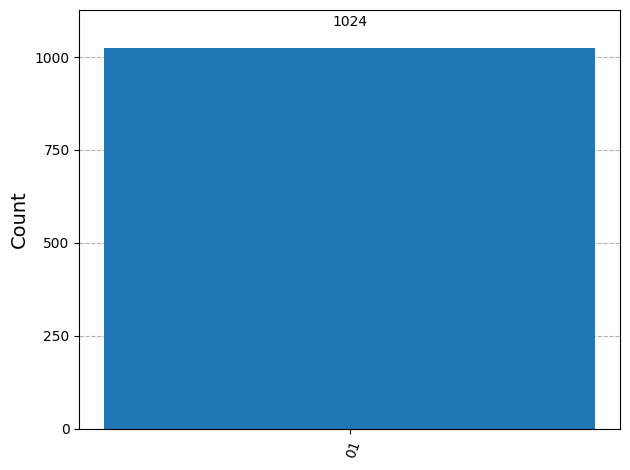

In [182]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

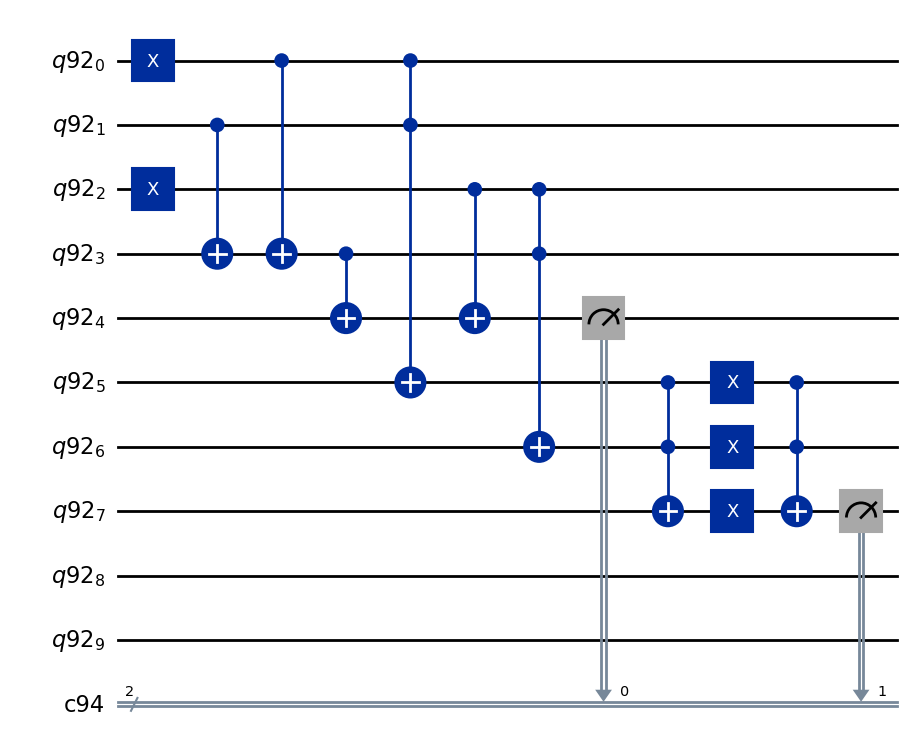

In [183]:
#circuit for 101
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[0])
circuit.x(qr[2])

circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

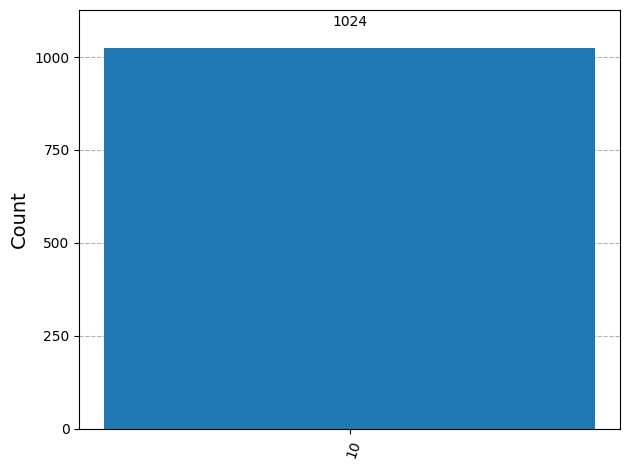

In [184]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

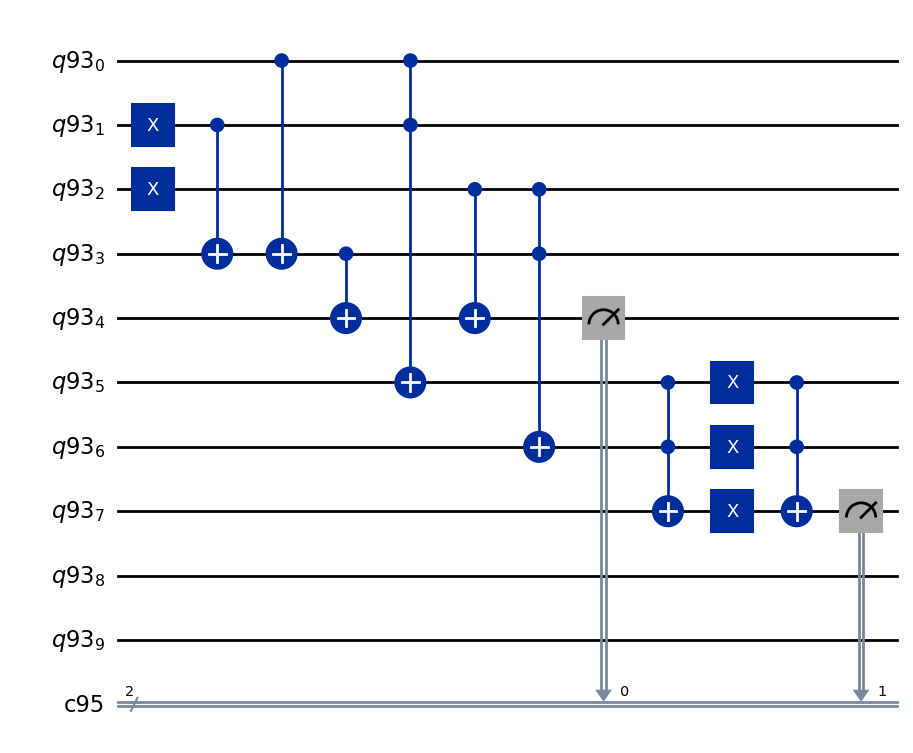

In [185]:
#circuit for 110
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[1])
circuit.x(qr[2])

circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

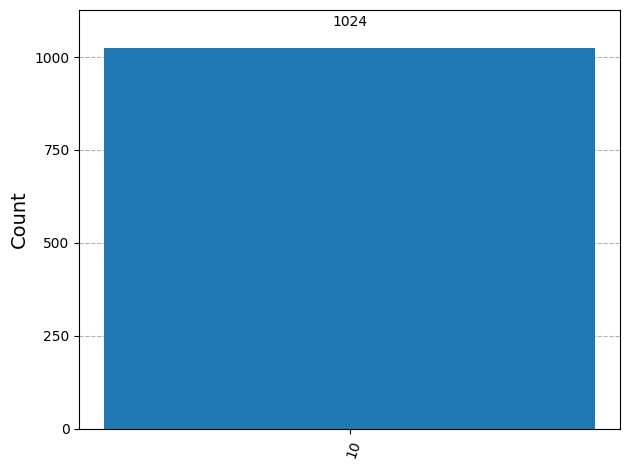

In [186]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

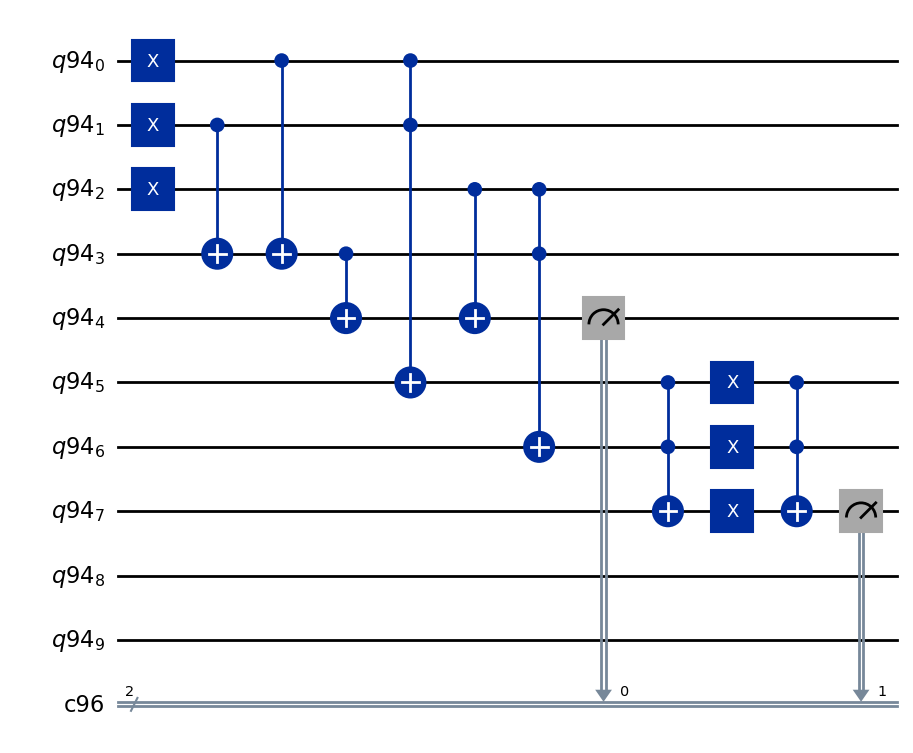

In [187]:
#circuit for 111
qr = QuantumRegister(10)
cr = ClassicalRegister(2)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[0])
circuit.x(qr[1])
circuit.x(qr[2])

circuit.cx(qr[1],qr[3])
circuit.cx(qr[0],qr[3])
circuit.cx(qr[3],qr[4])
circuit.cx(qr[2],qr[4])
circuit.ccx(qr[0],qr[1],qr[5])
circuit.ccx(qr[2],qr[3],qr[6])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.x(qr[5])
circuit.x(qr[6])
circuit.x(qr[7])
circuit.ccx(qr[5],qr[6],qr[7])
circuit.measure(qr[4], cr[0])
circuit.measure(qr[7], cr[1])
circuit.draw('mpl')

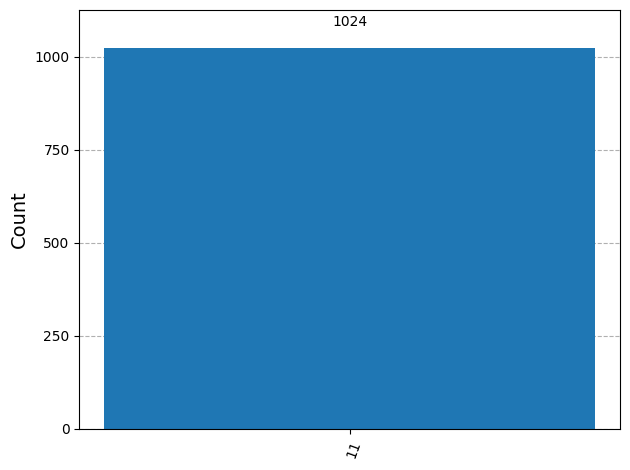

In [188]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

#### Exercise 2 : Phase Change with Q-Sphere
Build following 4 circuits: Z|0>, Z|1>, Z|+>, and Z|->, transpile, run, then see the difference and discuss results

Hint: you won't be able to see the difference in computational basis, try to use IQM Qiskit Composer to see phase information

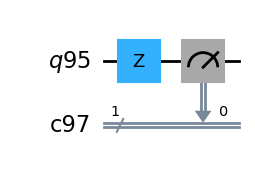

In [189]:
#circuit for Z|0>
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.z(qr[0])
circuit.measure(qr[0], cr[0])
circuit.draw('mpl')

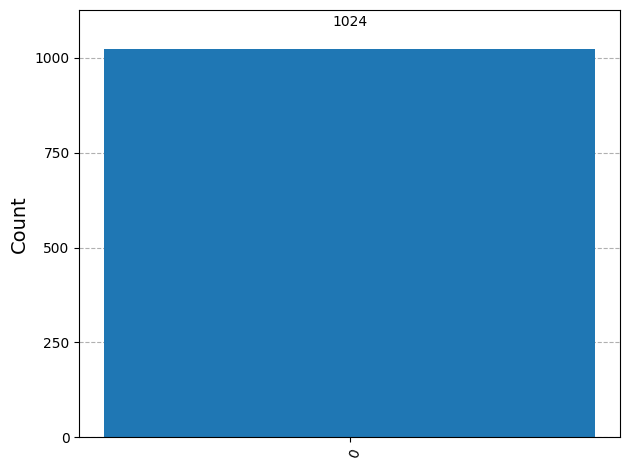

In [190]:
transpiled_circuit = transpile(circuit, backend)

job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)


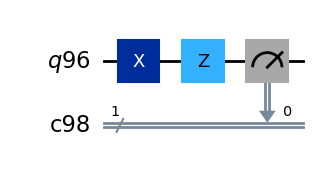

In [191]:
#circuit for Z|1>
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[0])
circuit.z(qr[0])
circuit.measure(qr[0], cr[0])
circuit.draw('mpl')

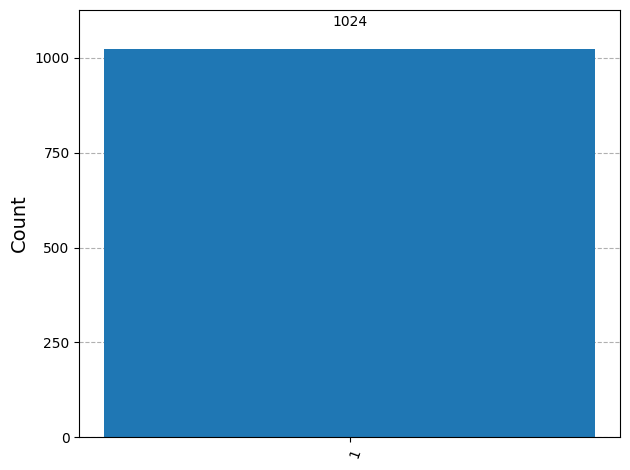

In [192]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

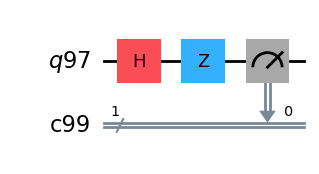

In [193]:
#circuit for Z|+>
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.h(qr[0])
circuit.z(qr[0])
circuit.measure(qr[0], cr[0])
circuit.draw('mpl')

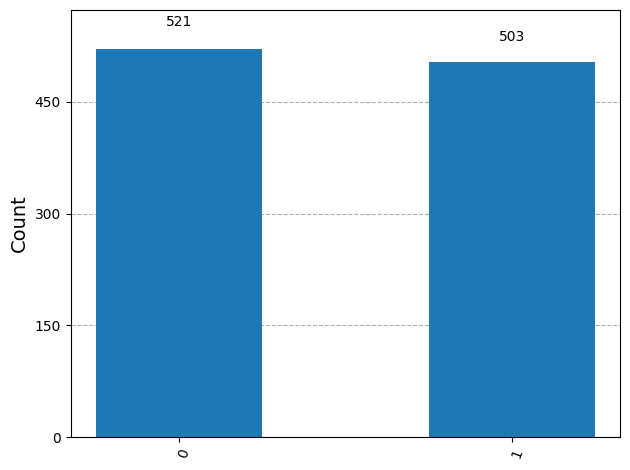

In [194]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

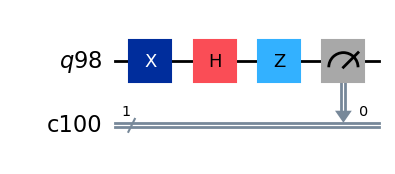

In [195]:
#circuit for Z|->
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.x(qr[0])
circuit.h(qr[0])
circuit.z(qr[0])
circuit.measure(qr[0], cr[0])
circuit.draw('mpl')

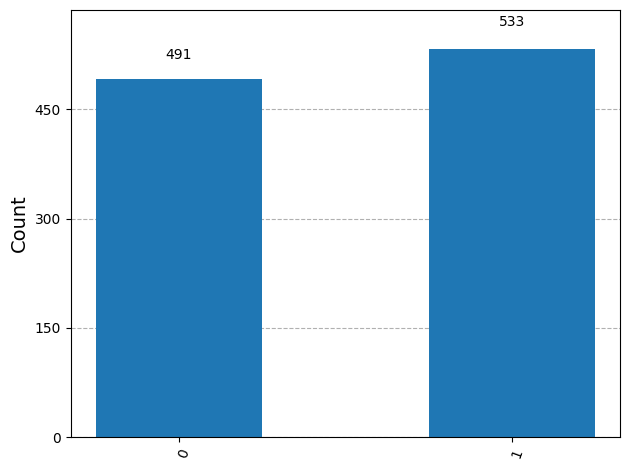

In [196]:
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
counts = job.result().get_counts()
plot_histogram(counts)

# discuss the differences here

    Z|0> = |0> and Z|1> =  |1> ,because Z gate are rotate over z-axis, noting change.

    Z|-> = |+> and Z|+> = |-> , because |-> and |+> are in hadamard basis and hadamard basis orthogonal with computational basis so when applie Z-gate will change state in 180 degree over z-axis.